## Proyecto Final — Minería de Datos  
## Clasificación de Diabetes · Pima Indians Dataset
### KNN + Regresión Logística Tuneados con GridSearchCV

In [32]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from scipy import stats
from scipy.stats import shapiro, spearmanr, pearsonr, chi2_contingency
from scipy.spatial.distance import mahalanobis

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, classification_report,
    average_precision_score, precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

---
## BLOQUE 1 — Estadística Descriptiva y Exploratoria
### Paso 1 · Cargar datos y revisar el diccionario de variables

In [33]:
df_train = pd.read_csv('Training.csv')
df_test  = pd.read_csv('Testing.csv')

print(f'Training : {df_train.shape[0]} filas x {df_train.shape[1]} columnas')
print(f'Testing  : {df_test.shape[0]}  filas x {df_test.shape[1]}  columnas')
df_train.head(8)

Training : 2460 filas x 9 columnas
Testing  : 308  filas x 9  columnas


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6000,0.6270,50,1
1,1,85,66,29,0,26.6000,0.3510,31,0
2,8,183,64,0,0,23.3000,0.6720,32,1
3,1,89,66,23,94,28.1000,0.1670,21,0
4,0,137,40,35,168,43.1000,2.2880,33,1
5,5,116,74,0,0,25.6000,0.2010,30,0
6,3,78,50,32,88,31.0000,0.2480,26,1
7,10,115,0,0,0,35.3000,0.1340,29,0


In [34]:
# Diccionario de variables
diccionario = pd.DataFrame({
    'Variable'   : df_train.columns,
    'Rol'        : ['Input']*8 + ['Output'],
    'Tipo'       : ['Cuantitativa discreta', 'Cuantitativa continua', 'Cuantitativa continua',
                    'Cuantitativa continua', 'Cuantitativa continua', 'Cuantitativa continua',
                    'Cuantitativa continua', 'Cuantitativa discreta', 'Cualitativa binaria'],
    'Descripción': ['Número de embarazos', 'Nivel de Glucosa en sangre',
                    'Nivel de Presión arterial', 'Grosor de la piel(mm)',
                    'Nivel de insulina en Sangre', 'Índice de masa corporal',
                    'Porcentaje de diabetes', 'Edad (años)',
                    '0=Sin diabetes · 1=Con diabetes']
})
diccionario

,Variable,Rol,Tipo,Descripción
0,Pregnancies,Input,Cuantitativa discreta,Número de embarazos
1,Glucose,Input,Cuantitativa continua,Nivel de Glucosa en sangre
2,BloodPressure,Input,Cuantitativa continua,Nivel de Presión arterial
3,SkinThickness,Input,Cuantitativa continua,Grosor de la piel(mm)
4,Insulin,Input,Cuantitativa continua,Nivel de insulina en Sangre
5,BMI,Input,Cuantitativa continua,Índice de masa corporal
6,DiabetesPedigreeFunction,Input,Cuantitativa continua,Porcentaje de diabetes
7,Age,Input,Cuantitativa discreta,Edad (años)
8,Outcome,Output,Cualitativa binaria,0=Sin diabetes · 1=Con diabetes


In [35]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2460 entries, 0 to 2459
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2460 non-null   int64  
 1   Glucose                   2460 non-null   int64  
 2   BloodPressure             2460 non-null   int64  
 3   SkinThickness             2460 non-null   int64  
 4   Insulin                   2460 non-null   int64  
 5   BMI                       2460 non-null   float64
 6   DiabetesPedigreeFunction  2460 non-null   float64
 7   Age                       2460 non-null   int64  
 8   Outcome                   2460 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 173.1 KB


### Paso 2 · Análisis Univariado
Media, mediana, moda, IQR, CV, asimetría y curtosis para cada variable.

In [36]:
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

stats_uni = pd.DataFrame(index=features)
stats_uni['Media']     = df_train[features].mean()
stats_uni['Mediana']   = df_train[features].median()
# mode()[0] maneja correctamente variables con múltiples modas (toma la menor)
stats_uni['Moda']      = df_train[features].apply(lambda x: x.mode()[0])
stats_uni['Q1']        = df_train[features].quantile(0.25)
stats_uni['Q3']        = df_train[features].quantile(0.75)
stats_uni['IQR']       = stats_uni['Q3'] - stats_uni['Q1']
stats_uni['CV (%)']    = (df_train[features].std() / df_train[features].mean() * 100).round(2)
stats_uni['Asimetría'] = df_train[features].skew()
stats_uni['Curtosis']  = df_train[features].kurtosis()

print('Estadística Univariada:')
stats_uni.style.background_gradient(cmap='Blues', subset=['Media','Mediana'])\
               .format('{:.3f}')

Estadística Univariada:


,Media,Mediana,Moda,Q1,Q3,IQR,CV (%),Asimetría,Curtosis
Pregnancies,3.817,3.000,1.000,1.000,6.000,5.000,86.350,0.962,0.583
Glucose,121.602,117.000,100.000,100.000,142.000,42.000,26.140,0.123,0.774
BloodPressure,68.915,70.000,70.000,64.000,80.000,16.000,27.690,-1.943,5.539
SkinThickness,20.531,23.000,0.000,0.000,33.000,33.000,76.550,-0.026,-1.166
Insulin,80.120,36.000,0.000,0.000,129.000,129.000,145.740,2.349,7.705
BMI,31.990,32.100,31.600,27.100,36.500,9.400,24.390,-0.364,3.036
DiabetesPedigreeFunction,0.491,0.381,0.254,0.252,0.647,0.395,74.050,2.151,6.431
Age,32.822,29.000,21.000,24.000,39.000,15.000,34.280,1.250,1.287


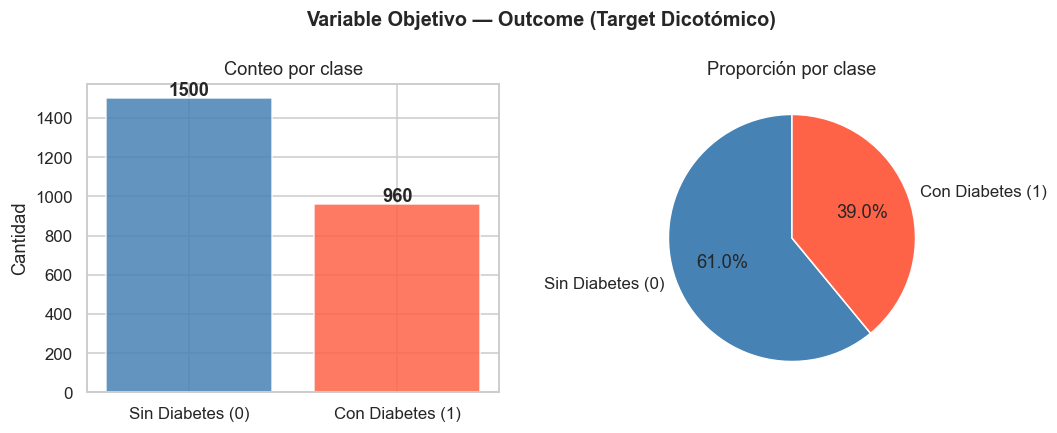

In [37]:
# Distribución de la variable objetivo
conteo = df_train['Outcome'].value_counts()
labels = ['Sin Diabetes (0)', 'Con Diabetes (1)']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, conteo, color=['steelblue','tomato'], alpha=0.85)
axes[0].set_title('Conteo por clase')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo):
    axes[0].text(i, v+15, str(v), ha='center', fontweight='bold')
axes[1].pie(conteo, labels=labels, autopct='%1.1f%%',
            colors=['steelblue','tomato'], startangle=90)
axes[1].set_title('Proporción por clase')
plt.suptitle('Variable Objetivo — Outcome (Target Dicotómico)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Paso 3 · Visualización Exploratoria

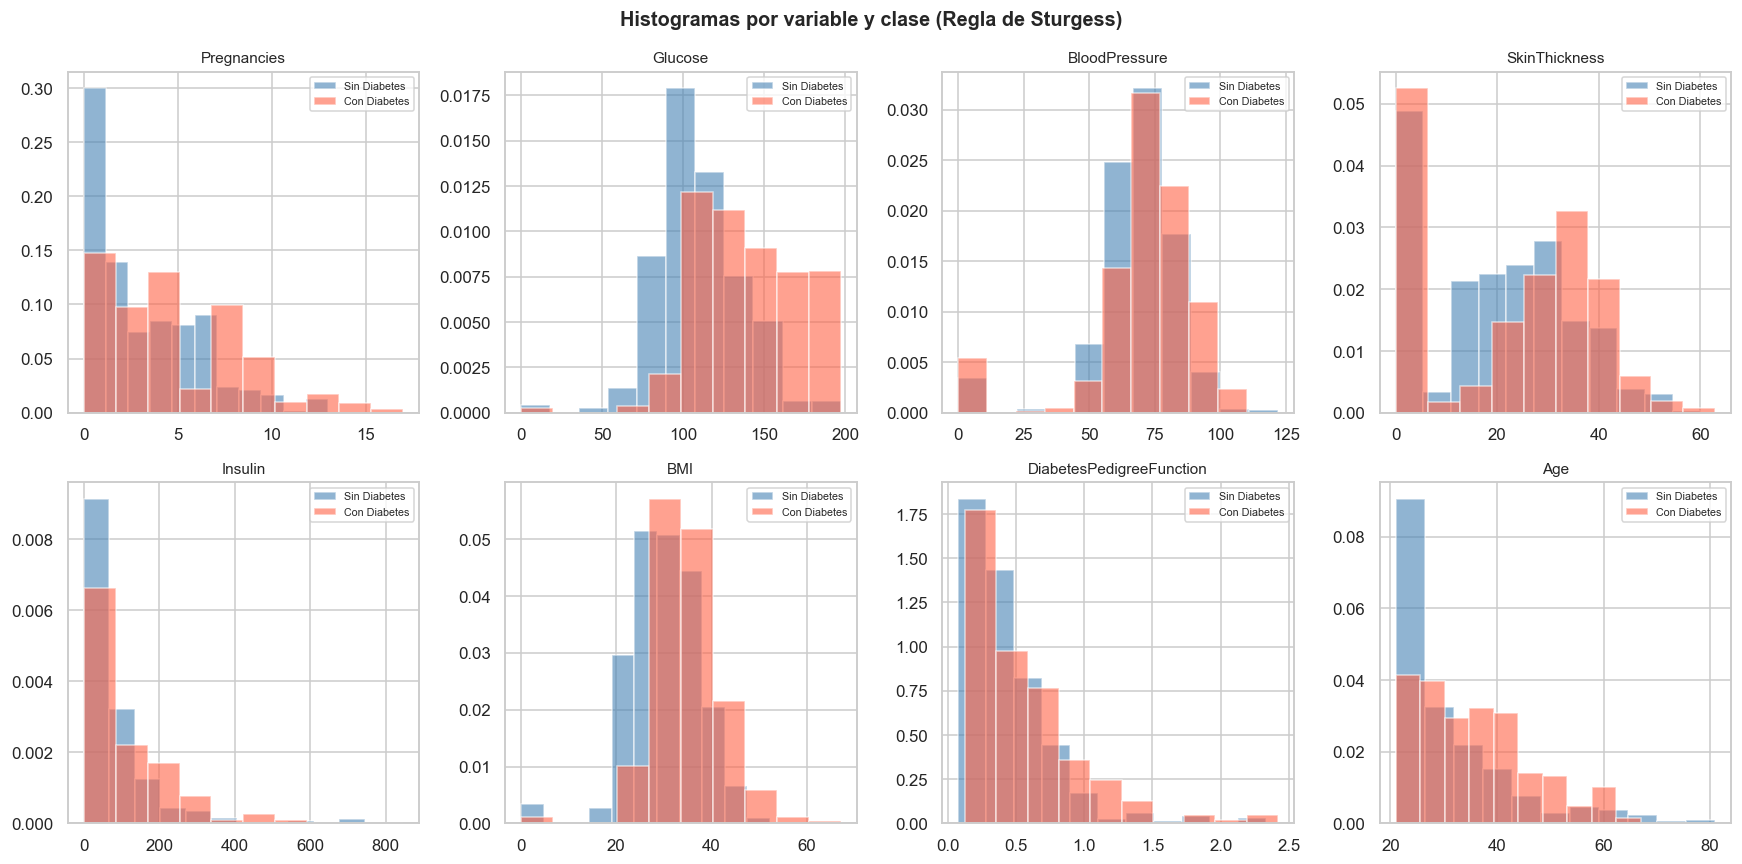

In [38]:
# Histogramas por variable y clase
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), features):
    for val, color, label in [(0,'steelblue','Sin Diabetes'), (1,'tomato','Con Diabetes')]:
        datos = df_train[df_train['Outcome']==val][col]
        n_bins = int(1 + 3.322 * np.log10(len(datos)))  # Regla de Sturgess
        ax.hist(datos, bins=n_bins, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Histogramas por variable y clase (Regla de Sturgess)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

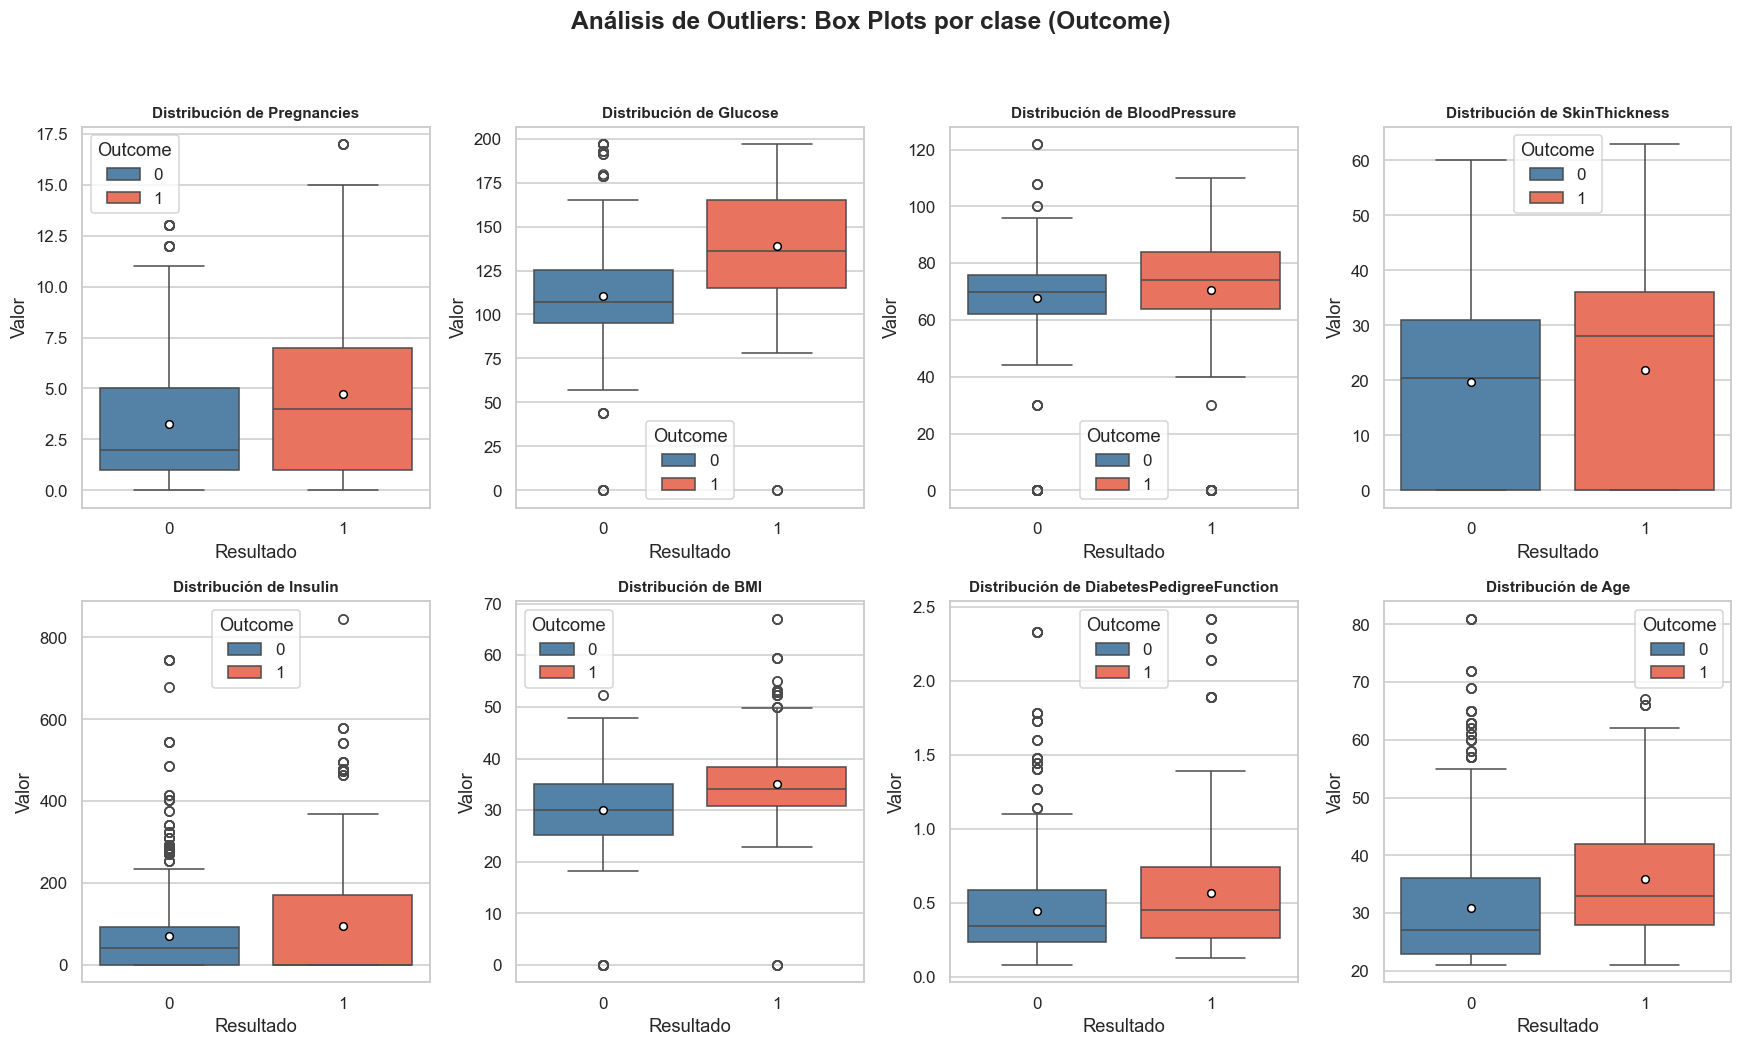

In [39]:
custom_palette = {0: 'steelblue', 1: 'tomato', '0': 'steelblue', '1': 'tomato'}

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(
        data=df_train, x='Outcome', y=col, hue='Outcome', ax=ax,
        palette=custom_palette, showmeans=True,
        meanprops={"marker":"o", "markerfacecolor":"white",
                   "markeredgecolor":"black", "markersize":"5"}
    )
    ax.set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Resultado')
    ax.set_ylabel('Valor')

plt.suptitle('Análisis de Outliers: Box Plots por clase (Outcome)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Paso 4 · Prueba de Normalidad — Shapiro-Wilk
> **H₀:** la variable se aproxima a distribución normal  
> **p-valor < 5%** → Rechazar H₀ → Variable NO es normal → usar Spearman

In [40]:
ALPHA = 0.05
resultados_norm = []

for col in features:
    muestra = df_train[col].dropna().sample(min(2000, len(df_train)), random_state=42)
    stat, p = shapiro(muestra)
    resultados_norm.append({
        'Variable'        : col,
        'Estadístico'     : round(stat, 4),
        'p-valor'         : round(p, 4),
        'Normal?'         : 'SÍ' if p > ALPHA else 'NO',
        'Prueba bivariada': 'Pearson' if p > ALPHA else 'Spearman (n>100)'
    })

df_norm = pd.DataFrame(resultados_norm).set_index('Variable')
df_norm.style.map(
    lambda v: 'color:green;font-weight:bold' if v == 'SÍ'
    else ('color:red;font-weight:bold' if v == 'NO' else ''),
    subset=['Normal?']
)

,Estadístico,p-valor,Normal?,Prueba bivariada
Variable,,,,
Pregnancies,0.906800,0.000000,NO,Spearman (n>100)
Glucose,0.967200,0.000000,NO,Spearman (n>100)
BloodPressure,0.806000,0.000000,NO,Spearman (n>100)
SkinThickness,0.907100,0.000000,NO,Spearman (n>100)
Insulin,0.713300,0.000000,NO,Spearman (n>100)
BMI,0.954200,0.000000,NO,Spearman (n>100)
DiabetesPedigreeFunction,0.810000,0.000000,NO,Spearman (n>100)
Age,0.872400,0.000000,NO,Spearman (n>100)


### Paso 5 · Análisis Bivariado — Correlación Spearman

 Análisis Variable vs Variable

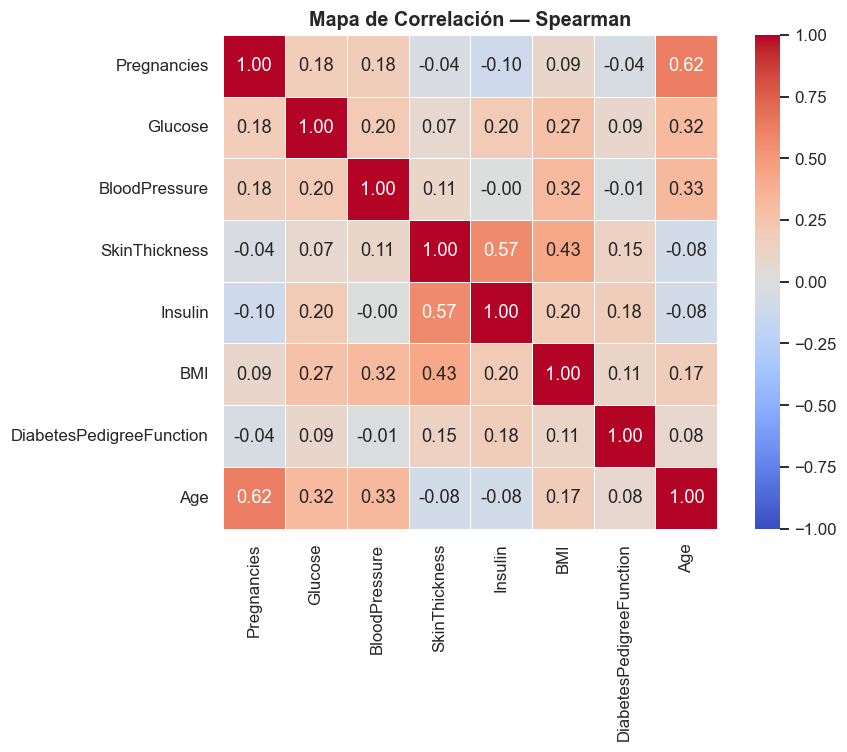

In [41]:
corr_spearman = df_train[features].corr(method='spearman')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Mapa de Correlación — Spearman', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# ANOVA / Kruskal-Wallis: Variables numéricas vs Outcome
def test_num_vs_cat(num_col, cat_col, df):
    grupos = [g.dropna().values for _, g in df.groupby(cat_col)[num_col]]
    grupos = [g for g in grupos if len(g) > 1]
    if len(grupos) < 2:
        return None
    _, p_lev         = stats.levene(*grupos)
    f_anova, p_anova = stats.f_oneway(*grupos)
    h_kw, p_kw       = stats.kruskal(*grupos)
    usar             = 'ANOVA' if p_lev > ALPHA else 'Kruskal-Wallis'
    p_final          = p_anova if usar == 'ANOVA' else p_kw
    return {
        'Variable numérica': num_col,
        'p_levene'         : round(p_lev,   4),
        'Var. homogéneas?' : 'SÍ' if p_lev > ALPHA else 'NO',
        'F / H estadístico': round(f_anova if usar == 'ANOVA' else h_kw, 4),
        'Prueba preferida' : usar,
        'p_final'          : round(p_final, 4),
        'Diferencia sig.?' : 'SÍ ✔' if p_final < ALPHA else 'NO ✘'
    }

resultados_anova = [test_num_vs_cat(col, 'Outcome', df_train) for col in features]
df_anova = pd.DataFrame(resultados_anova).set_index('Variable numérica')
df_anova.style.map(
    lambda v: 'color:green;font-weight:bold' if v in ('SÍ ✔', 'SÍ')
    else ('color:red;font-weight:bold'  if v in ('NO ✘', 'NO') else ''),
    subset=['Var. homogéneas?', 'Diferencia sig.?']
)

,p_levene,Var. homogéneas?,F / H estadístico,Prueba preferida,p_final,Diferencia sig.?
Variable numérica,,,,,,
Pregnancies,0.000000,NO,87.598500,Kruskal-Wallis,0.000000,SÍ ✔
Glucose,0.000000,NO,498.260100,Kruskal-Wallis,0.000000,SÍ ✔
BloodPressure,0.000100,NO,55.502100,Kruskal-Wallis,0.000000,SÍ ✔
SkinThickness,0.000000,NO,22.333200,Kruskal-Wallis,0.000000,SÍ ✔
Insulin,0.000000,NO,8.713800,Kruskal-Wallis,0.003200,SÍ ✔
BMI,0.002200,NO,242.518800,Kruskal-Wallis,0.000000,SÍ ✔
DiabetesPedigreeFunction,0.000000,NO,71.651600,Kruskal-Wallis,0.000000,SÍ ✔
Age,0.056400,SÍ,121.874500,ANOVA,0.000000,SÍ ✔


---
## BLOQUE 2 — Identificación y Tratamiento de Valores Faltantes
### Paso 6 · Identificar tipo de dato faltante y tratar

In [43]:
cols_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

reporte = []
for col in cols_ceros:
    n   = (df_train[col] == 0).sum()
    pct = n / len(df_train) * 100
    accion = ('Imputar (< 1% → trivial)'                if pct < 1
              else 'Imputar por mediana de clase'         if pct <= 5
              else 'Imputar por mediana de clase (mod.)'  if pct <= 15
              else '⚠ Crítico → imputar por mediana de clase + documentar')
    reporte.append({'Variable': col, 'Ceros': n, '% Faltante': round(pct,2), 'Acción': accion})

pd.DataFrame(reporte).set_index('Variable')

,Ceros,% Faltante,Acción
Variable,,,
Glucose,17,0.6900,Imputar (< 1% → trivial)
BloodPressure,114,4.6300,Imputar por mediana de clase
SkinThickness,717,29.1500,⚠ Crítico → imputar por mediana de clase + doc...
Insulin,1181,48.0100,⚠ Crítico → imputar por mediana de clase + doc...
BMI,31,1.2600,Imputar por mediana de clase


In [44]:
def reemplazar_ceros_por_nan(df, columnas):
    df = df.copy()
    df[columnas] = df[columnas].replace(0, np.nan)
    return df

def imputar_por_mediana_clase(df_in, df_ref, columnas, target='Outcome'):
    """Imputa NaN con la mediana de cada clase calculada en df_ref (evita data leakage)."""
    df = df_in.copy()
    for col in columnas:
        medianas = df_ref.groupby(target)[col].median()
        for clase, mediana in medianas.items():
            mask = df['Outcome'] == clase
            df.loc[mask & df[col].isna(), col] = mediana
        df[col] = df[col].fillna(df_ref[col].median())
    return df

df_train_c = reemplazar_ceros_por_nan(df_train, cols_ceros)
df_test_c  = reemplazar_ceros_por_nan(df_test,  cols_ceros)

df_train_c = imputar_por_mediana_clase(df_train_c, df_train_c, cols_ceros)
df_test_c  = imputar_por_mediana_clase(df_test_c,  df_train_c, cols_ceros)

print('Nulos restantes — Train:', df_train_c.isnull().sum().sum())
print('Nulos restantes — Test :', df_test_c.isnull().sum().sum())

Nulos restantes — Train: 0
Nulos restantes — Test : 0


---
## BLOQUE 3 — Identificación y Tratamiento de Outliers
### Paso 7 · Detectar outliers univariados

In [45]:
reporte_out = []
for col in features:
    serie = df_train_c[col]
    _, p_sw = shapiro(serie.sample(min(2000, len(serie)), random_state=42))
    es_normal = p_sw > ALPHA
    if es_normal:
        mu, s = serie.mean(), serie.std()
        mask  = (np.abs(serie - mu) / s) > 3
        criterio = 'Normal → |z| > 3'
    else:
        Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
        IQR = Q3 - Q1
        mask = (serie < Q1 - 3*IQR) | (serie > Q3 + 3*IQR)
        criterio = 'NO Normal → IQR×3'
    reporte_out.append({
        'Variable'   : col,
        'Normal?'    : 'SÍ' if es_normal else 'NO',
        'Criterio'   : criterio,
        'Outliers'   : mask.sum(),
        '% del total': round(mask.sum()/len(serie)*100, 2)
    })

pd.DataFrame(reporte_out).set_index('Variable')

,Normal?,Criterio,Outliers,% del total
Variable,,,,
Pregnancies,NO,NO Normal → IQR×3,0,0.0000
Glucose,NO,NO Normal → IQR×3,0,0.0000
BloodPressure,NO,NO Normal → IQR×3,0,0.0000
SkinThickness,NO,NO Normal → IQR×3,8,0.3300
Insulin,NO,NO Normal → IQR×3,54,2.2000
BMI,NO,NO Normal → IQR×3,3,0.1200
DiabetesPedigreeFunction,NO,NO Normal → IQR×3,35,1.4200
Age,NO,NO Normal → IQR×3,0,0.0000


### Paso 8 · Tratar outliers — Winsorizing IQR×3

In [46]:
# Los límites de winsorizing SE CALCULAN SOLO EN TRAIN y se aplican a test.
# Calcular cuantiles del test por separado sería data leakage.
def winsorizing_iqr(df, columnas, bounds=None, factor=3.0):
    """
    Winsorizing con IQR.
    - bounds=None  → calcula los límites desde df  (usar en TRAIN).
    - bounds=dict  → aplica los límites ya calculados (usar en TEST).
    Retorna (df_procesado, bounds_dict).
    """
    df = df.copy()
    if bounds is None:
        bounds = {}
        for col in columnas:
            Q1  = df[col].quantile(0.25)
            Q3  = df[col].quantile(0.75)
            IQR = Q3 - Q1
            bounds[col] = (Q1 - factor * IQR, Q3 + factor * IQR)
    for col in columnas:
        lo, hi = bounds[col]
        df[col] = df[col].clip(lower=lo, upper=hi)
    return df, bounds

# Train calcula los límites; test recibe los mismos límites (sin ver sus propios cuantiles)
df_train_c, win_bounds = winsorizing_iqr(df_train_c, features)
df_test_c,  _          = winsorizing_iqr(df_test_c,  features, bounds=win_bounds)

print('Winsorizing IQR×3 aplicado. Límites calculados SOLO desde train:')
df_train_c[features].agg(['min','max']).T

Winsorizing IQR×3 aplicado. Límites calculados SOLO desde train:


,min,max
Pregnancies,0.0000,17.0000
Glucose,44.0000,197.0000
BloodPressure,30.0000,122.0000
SkinThickness,7.0000,57.0000
Insulin,14.0000,424.0000
BMI,18.2000,63.8000
DiabetesPedigreeFunction,0.0780,1.8328
Age,21.0000,81.0000


---
## BLOQUE 4 — Transformación y Escalado
### Paso 9 · Transformar distribuciones sesgadas (log1p si Asimetría > 1)

In [47]:
asimetria    = df_train_c[features].skew()
cols_sesgadas = asimetria[asimetria > 1].index.tolist()
print('Variables con sesgo positivo > 1:', cols_sesgadas)

df_train_t = df_train_c.copy()
df_test_t  = df_test_c.copy()

for col in cols_sesgadas:
    df_train_t[col] = np.log1p(df_train_t[col])
    df_test_t[col]  = np.log1p(df_test_t[col])

comparacion = pd.DataFrame({
    'As. antes'  : df_train_c[features].skew().round(3),
    'As. después': df_train_t[features].skew().round(3)
})
comparacion['Mejoró?'] = comparacion.apply(
    lambda r: 'SÍ ✔' if abs(r['As. después']) < abs(r['As. antes']) else '—', axis=1)
comparacion

Variables con sesgo positivo > 1: ['Insulin', 'DiabetesPedigreeFunction', 'Age']


,As. antes,As. después,Mejoró?
Pregnancies,0.9620,0.9620,—
Glucose,0.5180,0.5180,—
BloodPressure,0.2040,0.2040,—
SkinThickness,0.0810,0.0810,—
Insulin,1.5960,-0.1980,SÍ ✔
BMI,0.5200,0.5200,—
DiabetesPedigreeFunction,1.7130,1.0870,SÍ ✔
Age,1.2500,0.6520,SÍ ✔


### Paso 10 · Escalar — RobustScaler (hay outliers residuales)

In [48]:
X_train = df_train_t[features]
y_train = df_train_t['Outcome']
X_test  = df_test_t[features]
y_test  = df_test_t['Outcome']

scaler     = RobustScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=features)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=features)

print('Escalado RobustScaler completado.')
print(f'  Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')
print(f'  Nulos en train: {X_train_sc.isnull().sum().sum()}  |  en test: {X_test_sc.isnull().sum().sum()}')

Escalado RobustScaler completado.
  Train: (2460, 8)  |  Test: (308, 8)
  Nulos en train: 0  |  en test: 0


---
## BLOQUE 5 — Modelado con GridSearchCV
### Target dicotómico: métricas correctas para clasificación binaria

Con un **target dicotómico (0/1)** las métricas relevantes son:

| Métrica | Qué mide | Cuándo priorizar |
|---------|----------|------------------|
| **ROC-AUC** | Capacidad discriminativa global | Siempre, especialmente con desbalance |
| **Recall (Sensibilidad)** | % diabéticos correctamente detectados | Cuando falso negativo es costoso (salud) |
| **Precision** | % de positivos predichos que son reales | Cuando falso positivo es costoso |
| **F1-Score** | Equilibrio Precision-Recall | Con clases desbalanceadas |
| **Accuracy** | Aciertos totales | Solo si clases están balanceadas |

> **Scoring en GridSearch:** se usa `roc_auc` (métrica más robusta para target dicotómico)  
> **CV:** StratifiedKFold (preserva proporción de clases en cada fold)

---
### Modelo 1 · KNN — GridSearchCV
Hiperparámetros buscados: `n_neighbors`, `weights`, `metric`

In [49]:
# ── Cross-validation estratificado (respeta proporción de clases) ──────────────
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Grid de hiperparámetros KNN ────────────────────────────────────────────────
param_grid_knn = {
    'n_neighbors': list(range(3, 26, 2)),   # impares: 3, 5, 7 … 25
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator  = KNeighborsClassifier(),
    param_grid = param_grid_knn,
    cv         = cv_strat,
    scoring    = 'roc_auc',   # métrica correcta para target dicotómico
    n_jobs     = -1,
    verbose    = 1,
    return_train_score = True
)
grid_knn.fit(X_train_sc, y_train)

print('\n══ Mejores hiperparámetros KNN ══')
for k, v in grid_knn.best_params_.items():
    print(f'  {k}: {v}')
print(f'\n  ROC-AUC (CV 5-fold): {grid_knn.best_score_:.4f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits

══ Mejores hiperparámetros KNN ══
  metric: euclidean
  n_neighbors: 5
  weights: distance

  ROC-AUC (CV 5-fold): 1.0000


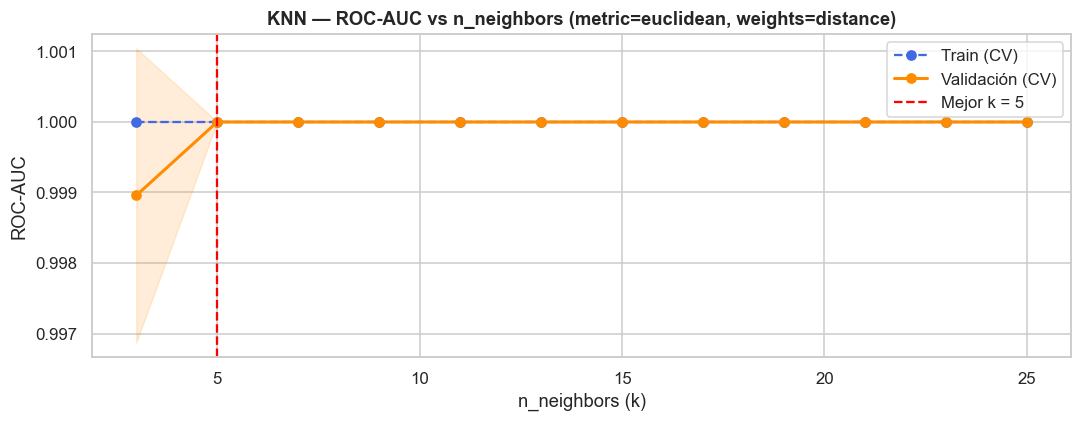

In [50]:
# Visualizar evolución del ROC-AUC según n_neighbors para los mejores pesos y métrica
cv_results = pd.DataFrame(grid_knn.cv_results_)

best_metric  = grid_knn.best_params_['metric']
best_weights = grid_knn.best_params_['weights']

mask_best = (
    (cv_results['param_metric']   == best_metric) &
    (cv_results['param_weights']  == best_weights)
)

subset = cv_results[mask_best].sort_values('param_n_neighbors')

plt.figure(figsize=(10, 4))
plt.plot(subset['param_n_neighbors'], subset['mean_train_score'],
         'o--', color='royalblue', label='Train (CV)', linewidth=1.5)
plt.plot(subset['param_n_neighbors'], subset['mean_test_score'],
         'o-',  color='darkorange', label='Validación (CV)', linewidth=2)
plt.fill_between(
    subset['param_n_neighbors'],
    subset['mean_test_score'] - subset['std_test_score'],
    subset['mean_test_score'] + subset['std_test_score'],
    alpha=0.15, color='darkorange'
)
plt.axvline(grid_knn.best_params_['n_neighbors'], color='red', linestyle='--',
            label=f"Mejor k = {grid_knn.best_params_['n_neighbors']}")
plt.title(f'KNN — ROC-AUC vs n_neighbors (metric={best_metric}, weights={best_weights})',
          fontsize=12, fontweight='bold')
plt.xlabel('n_neighbors (k)')
plt.ylabel('ROC-AUC')
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# ── Evaluación del mejor KNN en Test ──────────────────────────────────────────
knn_best   = grid_knn.best_estimator_
y_pred_knn = knn_best.predict(X_test_sc)
y_prob_knn = knn_best.predict_proba(X_test_sc)[:, 1]

print('══ KNN Tuneado — Reporte de Clasificación (Test) ══')
print(classification_report(y_test, y_pred_knn,
                             target_names=['Sin Diabetes (0)', 'Con Diabetes (1)']))

metricas_knn = {
    'Accuracy' : accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn),
    'Recall'   : recall_score(y_test, y_pred_knn),
    'F1-Score' : f1_score(y_test, y_pred_knn),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_knn),
    'Avg Precision': average_precision_score(y_test, y_prob_knn)
}
print('\nResumen de métricas (Test):')
for k, v in metricas_knn.items():
    print(f'  {k:20s}: {v:.4f}')

══ KNN Tuneado — Reporte de Clasificación (Test) ══
                  precision    recall  f1-score   support

Sin Diabetes (0)       0.90      0.87      0.88       215
Con Diabetes (1)       0.71      0.77      0.74        93

        accuracy                           0.84       308
       macro avg       0.81      0.82      0.81       308
    weighted avg       0.84      0.84      0.84       308


Resumen de métricas (Test):
  Accuracy            : 0.8377
  Precision           : 0.7129
  Recall              : 0.7742
  F1-Score            : 0.7423
  ROC-AUC             : 0.8269
  Avg Precision       : 0.6326


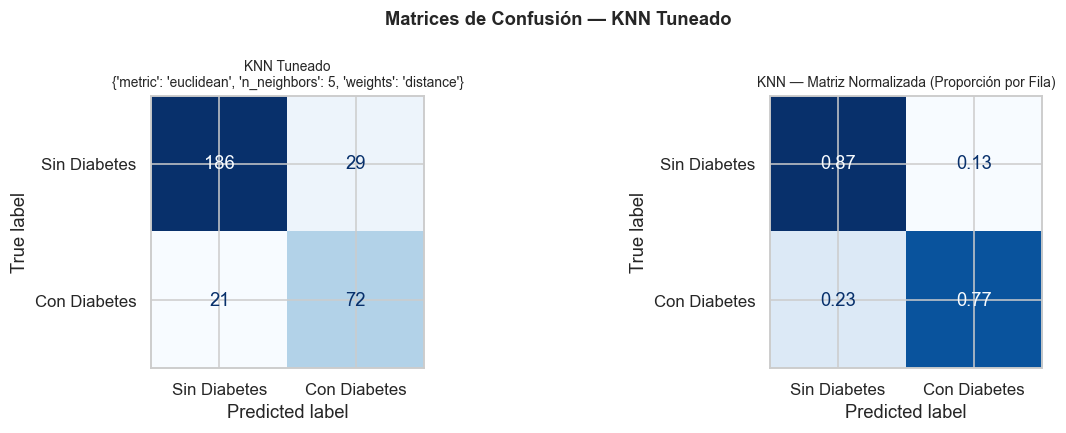

  TP (Diabéticos correctos)        : 72
  TN (Sanos correctos)             : 186
  FP (Falsos positivos)            : 29
  FN (Falsos negativos — riesgoso) : 21


In [52]:
# Matriz de confusión KNN
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=['Sin Diabetes','Con Diabetes'])\
    .plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'KNN Tuneado\n{grid_knn.best_params_}', fontsize=9)

# Normalizada
cm_norm = cm_knn.astype(float) / cm_knn.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=['Sin Diabetes','Con Diabetes'])\
    .plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('KNN — Matriz Normalizada (Proporción por Fila)', fontsize=9)

plt.suptitle('Matrices de Confusión — KNN Tuneado', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_knn.ravel()
print(f'  TP (Diabéticos correctos)        : {tp}')
print(f'  TN (Sanos correctos)             : {tn}')
print(f'  FP (Falsos positivos)            : {fp}')
print(f'  FN (Falsos negativos — riesgoso) : {fn}')

---
### Modelo 2 · Regresión Logística (Logit) — GridSearchCV
Hiperparámetros buscados: `C` (regularización), `penalty`, `solver`, `class_weight`

In [53]:
# ── Grid de hiperparámetros Logistic Regression ────────────────────────────────
# Combinaciones válidas solver-penalty:
#   liblinear → l1, l2
#   saga      → l1, l2
#   lbfgs     → l2 (solo)

param_grid_logit = [
    {
        'C'           : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty'     : ['l1', 'l2'],
        'solver'      : ['liblinear'],
        'class_weight': [None, 'balanced']
    },
    {
        'C'           : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty'     : ['l2'],
        'solver'      : ['lbfgs'],
        'class_weight': [None, 'balanced']
    },
    {
        'C'           : [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty'     : ['l1', 'l2'],
        'solver'      : ['saga'],
        'class_weight': [None, 'balanced']
    }
]

grid_logit = GridSearchCV(
    estimator  = LogisticRegression(max_iter=5000, random_state=42),
    param_grid = param_grid_logit,
    cv         = cv_strat,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1,
    return_train_score = True
)
grid_logit.fit(X_train_sc, y_train)

print('\n══ Mejores hiperparámetros Logit ══')
for k, v in grid_logit.best_params_.items():
    print(f'  {k}: {v}')
print(f'\n  ROC-AUC (CV 5-fold): {grid_logit.best_score_:.4f}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits

══ Mejores hiperparámetros Logit ══
  C: 0.1
  class_weight: balanced
  penalty: l1
  solver: liblinear

  ROC-AUC (CV 5-fold): 0.8755


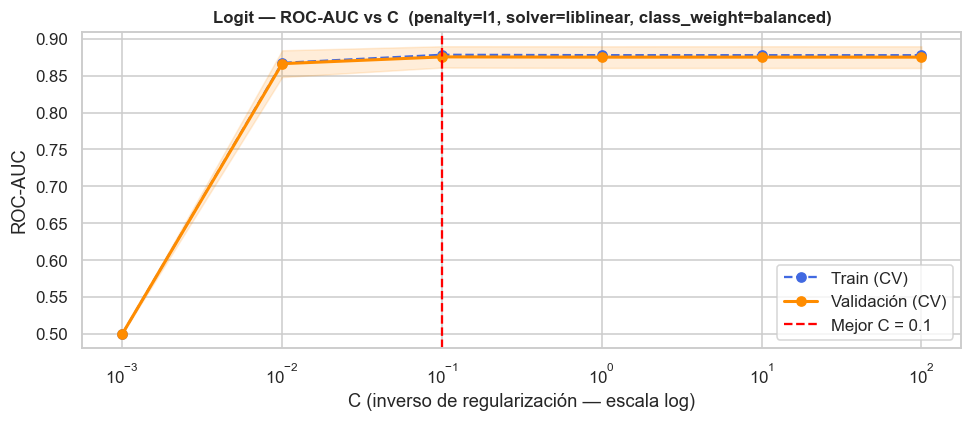

In [54]:
# Visualizar efecto del parámetro C en ROC-AUC para los mejores penalty/solver/class_weight
cv_res_logit = pd.DataFrame(grid_logit.cv_results_)

best_penalty = grid_logit.best_params_['penalty']
best_solver  = grid_logit.best_params_['solver']
best_cw      = grid_logit.best_params_['class_weight']

# Manejo correcto: si class_weight=None, pandas == None devuelve siempre False → usar isna()
if best_cw is None:
    mask_cw = cv_res_logit['param_class_weight'].isna()
else:
    mask_cw = cv_res_logit['param_class_weight'] == best_cw

mask = (
    (cv_res_logit['param_penalty'] == best_penalty) &
    (cv_res_logit['param_solver']  == best_solver)  &
    mask_cw
)
subset_l = cv_res_logit[mask].sort_values('param_C')

plt.figure(figsize=(9, 4))
plt.semilogx(subset_l['param_C'].astype(float), subset_l['mean_train_score'],
             'o--', color='royalblue', label='Train (CV)', linewidth=1.5)
plt.semilogx(subset_l['param_C'].astype(float), subset_l['mean_test_score'],
             'o-',  color='darkorange', label='Validación (CV)', linewidth=2)
plt.fill_between(
    subset_l['param_C'].astype(float),
    subset_l['mean_test_score'] - subset_l['std_test_score'],
    subset_l['mean_test_score'] + subset_l['std_test_score'],
    alpha=0.15, color='darkorange'
)
plt.axvline(grid_logit.best_params_['C'], color='red', linestyle='--',
            label=f"Mejor C = {grid_logit.best_params_['C']}")
plt.title(
    f'Logit — ROC-AUC vs C  (penalty={best_penalty}, solver={best_solver}, class_weight={best_cw})',
    fontsize=11, fontweight='bold'
)
plt.xlabel('C (inverso de regularización — escala log)')
plt.ylabel('ROC-AUC')
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# ── Evaluación del mejor Logit en Test ────────────────────────────────────────
logit_best   = grid_logit.best_estimator_
y_pred_logit = logit_best.predict(X_test_sc)
y_prob_logit = logit_best.predict_proba(X_test_sc)[:, 1]

print('══ Logit Tuneado — Reporte de Clasificación (Test) ══')
print(classification_report(y_test, y_pred_logit,
                             target_names=['Sin Diabetes (0)', 'Con Diabetes (1)']))

metricas_logit = {
    'Accuracy' : accuracy_score(y_test, y_pred_logit),
    'Precision': precision_score(y_test, y_pred_logit),
    'Recall'   : recall_score(y_test, y_pred_logit),
    'F1-Score' : f1_score(y_test, y_pred_logit),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_logit),
    'Avg Precision': average_precision_score(y_test, y_prob_logit)
}
print('\nResumen de métricas (Test):')
for k, v in metricas_logit.items():
    print(f'  {k:20s}: {v:.4f}')

══ Logit Tuneado — Reporte de Clasificación (Test) ══
                  precision    recall  f1-score   support

Sin Diabetes (0)       0.95      0.80      0.87       215
Con Diabetes (1)       0.66      0.89      0.76        93

        accuracy                           0.83       308
       macro avg       0.80      0.85      0.82       308
    weighted avg       0.86      0.83      0.84       308


Resumen de métricas (Test):
  Accuracy            : 0.8312
  Precision           : 0.6640
  Recall              : 0.8925
  F1-Score            : 0.7615
  ROC-AUC             : 0.9070
  Avg Precision       : 0.7457


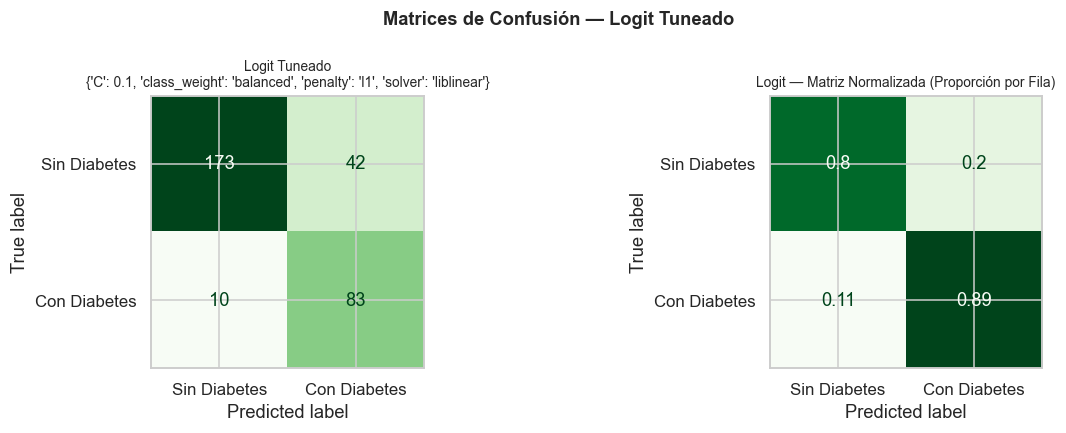

  TP (Diabéticos correctos)        : 83
  TN (Sanos correctos)             : 173
  FP (Falsos positivos)            : 42
  FN (Falsos negativos — riesgoso) : 10


In [56]:
# Matriz de confusión Logit
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_logit = confusion_matrix(y_test, y_pred_logit)
ConfusionMatrixDisplay(cm_logit, display_labels=['Sin Diabetes','Con Diabetes'])\
    .plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Logit Tuneado\n{grid_logit.best_params_}', fontsize=9)

cm_norm_l = cm_logit.astype(float) / cm_logit.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm_l.round(2), display_labels=['Sin Diabetes','Con Diabetes'])\
    .plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Logit — Matriz Normalizada (Proporción por Fila)', fontsize=9)

plt.suptitle('Matrices de Confusión — Logit Tuneado', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_logit.ravel()
print(f'  TP (Diabéticos correctos)        : {tp}')
print(f'  TN (Sanos correctos)             : {tn}')
print(f'  FP (Falsos positivos)            : {fp}')
print(f'  FN (Falsos negativos — riesgoso) : {fn}')

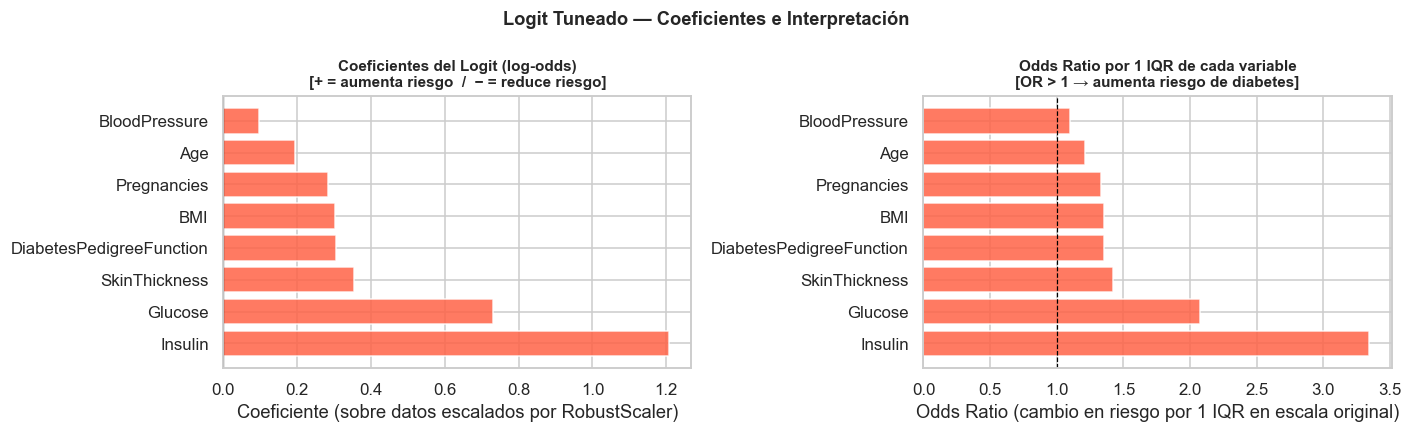


Tabla de coeficientes:
                Variable  Coeficiente  OR (por 1 IQR)  OR (por 1 unidad orig)
                 Insulin       1.2077          3.3458                  1.0147
                 Glucose       0.7316          2.0783                  1.0180
           SkinThickness       0.3546          1.4256                  1.0453
DiabetesPedigreeFunction       0.3052          1.3569                  2.1644
                     BMI       0.3028          1.3536                  1.0338
             Pregnancies       0.2849          1.3296                  1.0586
                     Age       0.1946          1.2148                  1.0131
           BloodPressure       0.0973          1.1021                  1.0061


In [57]:
# ── Coeficientes e interpretación del Logit ───────────────────────────────────
# NOTA: Los datos están escalados con RobustScaler → X_scaled = (X - mediana) / IQR
# Por eso:
#   coef[i]       = cambio en log-odds por 1 unidad de X_scaled
#   exp(coef[i])  = OR asociado a un incremento de 1 IQR en la variable original
#
# Para obtener el OR por 1 unidad en escala original:
#   OR_original[i] = exp(coef[i] / IQR_train[i])

# IQR de cada variable en train original (post-winsorizing, pre-transformación)
iqr_train = df_train_c[features].quantile(0.75) - df_train_c[features].quantile(0.25)

coef_df = pd.DataFrame({
    'Variable'              : features,
    'Coeficiente'           : logit_best.coef_[0],
    'OR (por 1 IQR)'        : np.exp(logit_best.coef_[0]),          # interpretación escalada
    'OR (por 1 unidad orig)': np.exp(logit_best.coef_[0] / iqr_train.values)  # escala original
}).sort_values('Coeficiente', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_coef = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coeficiente']]
axes[0].barh(coef_df['Variable'], coef_df['Coeficiente'], color=colors_coef, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Coeficientes del Logit (log-odds)\n'
                   '[+ = aumenta riesgo  /  − = reduce riesgo]',
                   fontsize=10, fontweight='bold')
axes[0].set_xlabel('Coeficiente (sobre datos escalados por RobustScaler)')

colors_or = ['tomato' if v > 1 else 'steelblue' for v in coef_df['OR (por 1 IQR)']]
axes[1].barh(coef_df['Variable'], coef_df['OR (por 1 IQR)'], color=colors_or, alpha=0.85)
axes[1].axvline(1, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Odds Ratio por 1 IQR de cada variable\n'
                   '[OR > 1 → aumenta riesgo de diabetes]',
                   fontsize=10, fontweight='bold')
axes[1].set_xlabel('Odds Ratio (cambio en riesgo por 1 IQR en escala original)')

plt.suptitle('Logit Tuneado — Coeficientes e Interpretación',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTabla de coeficientes:')
print(coef_df.to_string(index=False))

---
## BLOQUE 6 — Comparación de Modelos Tuneados

In [58]:
# Tabla comparativa completa
df_comp = pd.DataFrame([
    {
        'Modelo'             : 'KNN Tuneado',
        'Mejores Hiperparáms': str(grid_knn.best_params_),
        'ROC-AUC (CV)'       : grid_knn.best_score_,
        'Accuracy'           : metricas_knn['Accuracy'],
        'Precision'          : metricas_knn['Precision'],
        'Recall'             : metricas_knn['Recall'],
        'F1-Score'           : metricas_knn['F1-Score'],
        'ROC-AUC (Test)'     : metricas_knn['ROC-AUC'],
        'Avg Precision'      : metricas_knn['Avg Precision'],
    },
    {
        'Modelo'             : 'Logit Tuneado',
        'Mejores Hiperparáms': str(grid_logit.best_params_),
        'ROC-AUC (CV)'       : grid_logit.best_score_,
        'Accuracy'           : metricas_logit['Accuracy'],
        'Precision'          : metricas_logit['Precision'],
        'Recall'             : metricas_logit['Recall'],
        'F1-Score'           : metricas_logit['F1-Score'],
        'ROC-AUC (Test)'     : metricas_logit['ROC-AUC'],
        'Avg Precision'      : metricas_logit['Avg Precision'],
    }
]).set_index('Modelo')

metricas_num = ['ROC-AUC (CV)', 'Accuracy', 'Precision', 'Recall', 'F1-Score',
                'ROC-AUC (Test)', 'Avg Precision']

df_comp[metricas_num].round(4).style.highlight_max(color='lightgreen', axis=0)\
                                    .highlight_min(color='#ffcccc',     axis=0)\
                                    .format('{:.4f}')

,ROC-AUC (CV),Accuracy,Precision,Recall,F1-Score,ROC-AUC (Test),Avg Precision
Modelo,,,,,,,
KNN Tuneado,1.0000,0.8377,0.7129,0.7742,0.7423,0.8269,0.6326
Logit Tuneado,0.8755,0.8312,0.6640,0.8925,0.7615,0.9070,0.7457


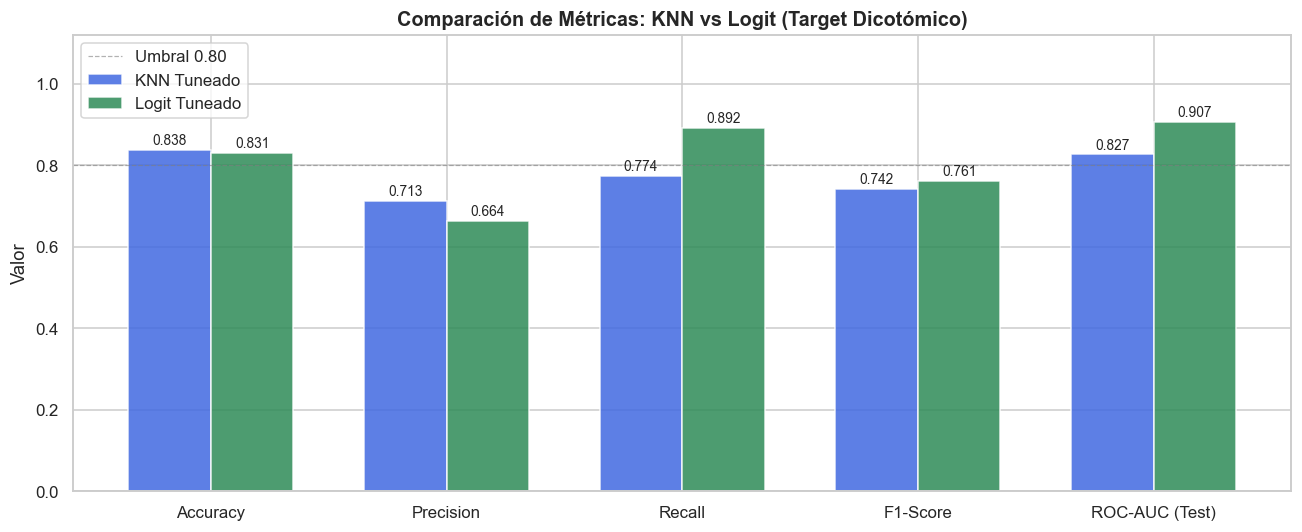

In [59]:
# Gráfico de barras comparativo
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC (Test)']
x     = np.arange(len(metricas_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, df_comp.loc['KNN Tuneado',   metricas_plot],
               width, label='KNN Tuneado',   color='royalblue', alpha=0.85)
bars2 = ax.bar(x + width/2, df_comp.loc['Logit Tuneado', metricas_plot],
               width, label='Logit Tuneado', color='seagreen',  alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, fontsize=11)
ax.set_ylim(0, 1.12)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Umbral 0.80')
ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas: KNN vs Logit (Target Dicotómico)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

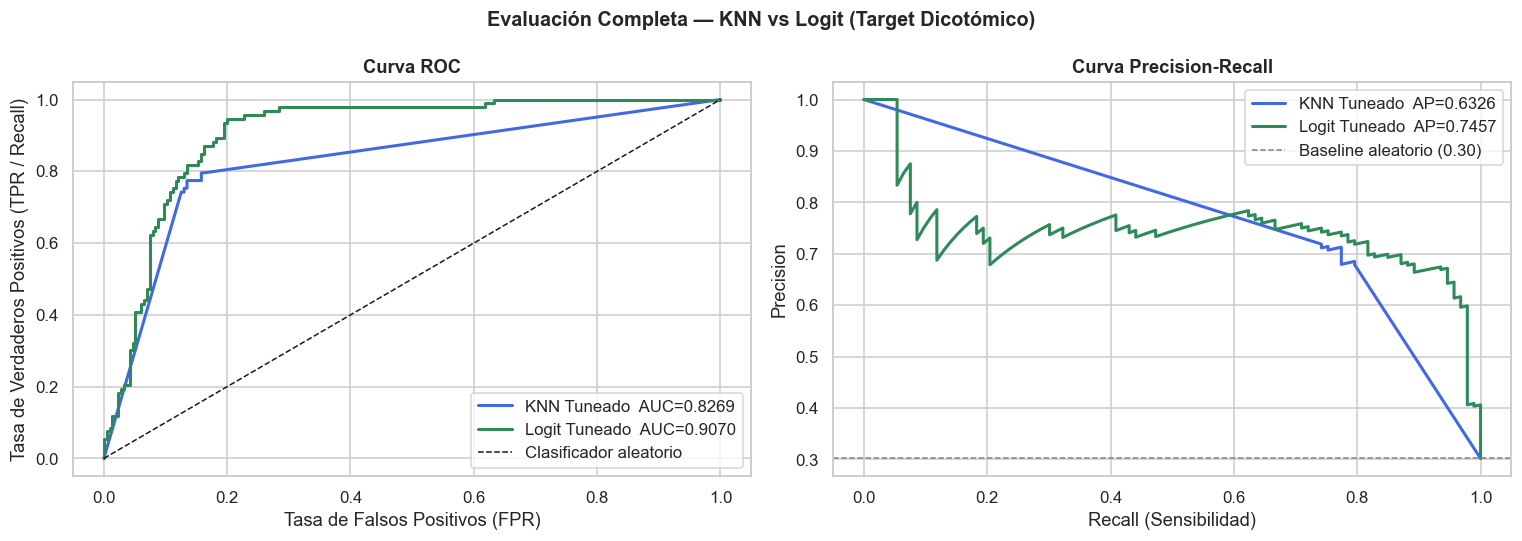

In [60]:
# Curvas ROC y Precision-Recall comparadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos_eval = [
    ('KNN Tuneado',   y_prob_knn,   'royalblue'),
    ('Logit Tuneado', y_prob_logit, 'seagreen')
]

# ── Curvas ROC ────────────────────────────────────────────────────────────────
for nombre, y_prob, color in modelos_eval:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{nombre}  AUC={auc:.4f}', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
axes[0].set_title('Curva ROC', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')

# ── Curvas Precision-Recall ───────────────────────────────────────────────────
for nombre, y_prob, color in modelos_eval:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap           = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{nombre}  AP={ap:.4f}', color=color, linewidth=2)

baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', linewidth=1,
                label=f'Baseline aleatorio ({baseline:.2f})')
axes[1].set_xlabel('Recall (Sensibilidad)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')

plt.suptitle('Evaluación Completa — KNN vs Logit (Target Dicotómico)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [61]:
# ── Determinar mejor modelo ────────────────────────────────────────────────────
mejor_nombre = df_comp['ROC-AUC (Test)'].idxmax()
peor_nombre  = df_comp['ROC-AUC (Test)'].idxmin()

print('══════════════════════════════════════════════════')
print(f'  MEJOR MODELO (ROC-AUC Test): {mejor_nombre}')
print('══════════════════════════════════════════════════')
print(df_comp.loc[mejor_nombre, metricas_num].to_string())
print()
print(f'  Diferencia ROC-AUC (Test) vs {peor_nombre}:',
      round(df_comp.loc[mejor_nombre,'ROC-AUC (Test)'] - df_comp.loc[peor_nombre,'ROC-AUC (Test)'], 4))

══════════════════════════════════════════════════
  MEJOR MODELO (ROC-AUC Test): Logit Tuneado
══════════════════════════════════════════════════
ROC-AUC (CV)     0.8755
Accuracy         0.8312
Precision        0.6640
Recall           0.8925
F1-Score         0.7615
ROC-AUC (Test)   0.9070
Avg Precision    0.7457

  Diferencia ROC-AUC (Test) vs KNN Tuneado: 0.0801


---
## Conclusiones

### Pipeline de preprocesamiento
| Paso | Acción |
|------|--------|
| Faltantes encubiertos | `Insulin` (~48%) y `SkinThickness` (~29%) imputados por mediana de clase |
| Outliers | Reales (no errores) → Winsorizing IQR×3 |
| Transformación | Variables con Asimetría > 1 → `log1p` |
| Escalado | `RobustScaler` (hay outliers residuales) |

### GridSearchCV — Elecciones metodológicas
| Decisión | Justificación |
|----------|---------------|
| `scoring='roc_auc'` | Target dicotómico con desbalance (~39/61%) → AUC es más informativo que accuracy |
| `StratifiedKFold(5)` | Preserva proporción de clases en cada fold → evita folds sin positivos |
| KNN: `metric` + `weights` + `n_neighbors` | Los 3 hiperparámetros interactúan: distancia afecta directamente el peso de vecinos |
| Logit: 3 listas en `param_grid` | Cada solver solo admite ciertas penalizaciones → evitar combinaciones inválidas |

### Métricas para target dicotómico
- **ROC-AUC**: mide la capacidad discriminativa global — clave con desbalance de clases
- **Recall**: mide cuántos diabéticos son detectados — en salud, el **falso negativo** es el error más costoso
- **Precision-Recall AUC**: complementa ROC cuando el desbalance es significativo
- **F1-Score**: equilibra precision y recall sin asumir clases balanceadas

### Variables más importantes
- Según los coeficientes del Logit: `Glucose` y `BMI` son los predictores con mayor odds ratio
- Un OR > 1 indica que al aumentar esa variable, **aumenta el riesgo de diabetes**